# Обработка последовательностей при помощи RNN

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Николенко С., Кадурин А., Архангельская Е. Глубокое обучение.
* https://pytorch.org/docs/stable/nn.html#recurrent-layers
* https://karpathy.github.io/2015/05/21/rnn-effectiveness/
* https://pytorch.org/docs/stable/generated/torch.nn.RNNCell.html
* https://blog.floydhub.com/a-beginners-guide-on-recurrent-neural-networks-with-pytorch/
* https://pytorch.org/tutorials/intermediate/char_rnn_classification_tutorial.html
* https://pytorch.org/tutorials/beginner/nlp/sequence_models_tutorial.html
* https://notebook.community/sameersingh/uci-statnlp/tutorials/rnn_examples
* https://github.com/bentrevett/pytorch-pos-tagging/blob/master/1_bilstm.ipynb
* https://github.com/Koziev/rupostagger

## Задачи для совместного разбора

1\. Рассмотрите пример работы одного шага простейшего рекуррентного слоя.  

$$ h' = tanh(W_{ih}x + W_{hh}h) $$

![RNN](https://kvitajakub.github.io/img/rnn-unrolled.png)

2\. Рассмотрите пример работы рекуррентных слоев из `torch.nn`.

In [1]:
import torch.nn as nn
import torch

In [2]:
batch_size, seq_len, input_size, hidden_size = 16, 8, 32, 10

x = torch.rand(batch_size, seq_len, input_size)

In [3]:
layer = nn.RNN(input_size=input_size, hidden_size=hidden_size, batch_first=True)

out, h = layer(x)

In [4]:
out[0, -1, :]

tensor([-0.1948, -0.2309,  0.6660,  0.1377, -0.0725, -0.2192,  0.0178, -0.2292,
         0.0583,  0.1156], grad_fn=<SliceBackward0>)

In [5]:
h[0, 0]

tensor([-0.1948, -0.2309,  0.6660,  0.1377, -0.0725, -0.2192,  0.0178, -0.2292,
         0.0583,  0.1156], grad_fn=<SelectBackward0>)

3\. Рассмотрите пример работы двунаправленного рекуррентого слоя

![bi-lstm](https://discuss.pytorch.org/uploads/default/original/3X/d/3/d34a27c490e75c1a0a96128c5726ab6656427d90.jpeg)

4\. Рассмотрите пример работы многоуровневого рекуррентого слоя

![stacked-rnn](https://lh6.googleusercontent.com/rC1DSgjlmobtRxMPFi14hkMdDqSkEkuOX7EW_QrLFSymjasIM95Za2Wf-VwSC1Tq1sjJlOPLJ92q7PTKJh2hjBoXQawM6MQC27east67GFDklTalljlt0cFLZnPMdhp8erzO)

## Задачи для самостоятельного решения

In [49]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from typing import List, Tuple, Dict
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from collections import Counter
import pytorch_lightning as pl
from torch.utils.data import DataLoader
from torchmetrics.classification import MulticlassAccuracy
import time
import pymorphy3
from sklearn.metrics import classification_report
from torchmetrics.classification import MulticlassF1Score

<p class="task" id="1"></p>

1\. Используя класс `nn.RNNCell` (абстракцию для отдельного временного шага RNN), реализуйте простейшую рекуррентную сеть в виде класса `RNN`. Предусмотрите возможность работы с форматом данных, где данные (x) представлены в виде (batch, seq, feature).

Создайте тензор `inputs1` размера 16 x 8 x 32 (batch, seq, feature) и пропустите через модель `RNN`. Выведите на экран форму двух полученных тензоров. Проверьте, что вектор последнего скрытого состояния из outputs поэлементно равен `h`.
- [ ] Проверено на семинаре

In [7]:
class RNN(nn.Module):
  def __init__(self, input_size, hidden_size):
    super().__init__()
    self.hidden_size = hidden_size
    self.cell = nn.RNNCell(input_size=input_size, hidden_size=hidden_size)


  def forward(self, x, h=None):
    '''
    x.shape = (batch_size, seq_len, feature_size) - тензор входных данных
    h.shape = (batch_size, hidden_size) - тензор со скрытым состоянием RNN
    '''
    batch_size, seq_len, feature_size = x.shape

    # инициализация тензора скрытых состояний
    if h is None:
      h = torch.zeros(batch_size, self.hidden_size, device=x.device)
      
    outputs = []
    # проход по каждому элементу последовательностей s в батче и обновление скрытого состояния
    for t in range(seq_len):
      x_t = x[:,t]
      h = self.cell(x_t, h)
      outputs.append(h)

    outputs = torch.stack(outputs, dim=1)

    # вернуть:
    #   outputs - тензор всех наблюдавшихся скрытых состояний размера (batch_size, seq_len, hidden_size) и
    #   h - тензор скрытых состояний в последний момент времени
    return outputs, h

In [8]:
batch_size, seq_len, input_size, hidden_size = 16, 8, 32, 10

inputs1 = torch.rand(batch_size, seq_len, input_size) 
model = RNN(input_size=input_size, hidden_size=hidden_size)


outputs, h_last = model(inputs1)
print(f"outputs.shape = {outputs.shape}") # [16, 8, 10]
print(f"h_last.shape = {h_last.shape}")  #  [16, 10]


output_last_step = outputs[:, -1]
is_equal = torch.allclose(output_last_step, h_last)
is_equal

outputs.shape = torch.Size([16, 8, 10])
h_last.shape = torch.Size([16, 10])


True

<p class="task" id="2"></p>

2\. Считайте файл `pets.csv`, приведите имена питомцев к нижнем регистру. Решите проблему с противоречивостью данных (некоторые имена встречаются в обоих классах). Разбейте набор данных на обучающую и тестовую выборку.  Создайте Tokenizer на основе обучающей выборки (токен - __буква__). Добавьте в словарь специальные токены `<PAD>` и `<UNK>`. Выведите на экран количество токенов в полученном словаре.

Создайте класс `PetsDataset`. Используя преобразования, сделайте длины наборов индексов одинаковой фиксированной длины (подходящее значение определите сами). Закодируйте целыми числами классы питомцев. Создайте два объекта класса `PetsDataset` (для обучающей и тестовой выборки). Выведите на экран их длины.

- [ ] Проверено на семинаре

In [9]:
df = pd.read_csv("data/pets.csv")
df.head()

,имя,класс
0,Арчи,собака
1,Алекс,собака
2,Амур,собака
3,Алтaй,собака
4,Альф,собака


In [10]:
df['имя'] = df['имя'].str.lower()

In [11]:
name_class_counts = df.groupby('имя')['класс'].nunique()
name_class_counts

имя
абби       1
абель      1
абигель    1
аватар     1
август     1
          ..
яся        2
яффи       1
яхонт      1
яша        1
яшма       2
Name: класс, Length: 2792, dtype: int64

In [12]:
kotopes_names = name_class_counts[name_class_counts > 1].index
kotopes_names

Index(['аврора', 'агнесса', 'ада', 'адель', 'айза', 'айрис', 'алиса', 'алиша',
       'альба', 'альма',
       ...
       'юста', 'юся', 'юта', 'юша', 'ягодка', 'ядвига', 'ямайка', 'яра', 'яся',
       'яшма'],
      dtype='object', name='имя', length=408)

In [13]:
df_clean = df[~df['имя'].isin(kotopes_names)].copy()
df_clean

,имя,класс
0,арчи,собака
1,алекс,собака
2,амур,собака
3,алтaй,собака
4,альф,собака
...,...,...
3223,ярика,кошка
3224,яриска,кошка
3225,ярка,кошка
3226,яркиса,кошка


In [14]:
unique_labels = df_clean['класс'].unique()
label2idx = {label: idx for idx, label in enumerate(unique_labels)}
df_clean['label_idx'] = df_clean['класс'].map(label2idx)
df_clean

,имя,класс,label_idx
0,арчи,собака,0
1,алекс,собака,0
2,амур,собака,0
3,алтaй,собака,0
4,альф,собака,0
...,...,...,...
3223,ярика,кошка,1
3224,яриска,кошка,1
3225,ярка,кошка,1
3226,яркиса,кошка,1


In [15]:
label2idx

{'собака': 0, 'кошка': 1}

(вау)

In [16]:
train, test = train_test_split(
    df_clean, 
    test_size=0.2, 
    stratify=df_clean['label_idx'], 
    random_state=42
)

print(train.shape)
print(test.shape)

(1915, 3)
(479, 3)


вспомним из далекой работы 01_2

In [17]:
class PadTruncate: 
    def __init__(self, n, pad_idx=0):
        self.n = n
        self.pad_idx = pad_idx
    
    def __call__(self, text):
        if len(text) >= self.n:
            return text[:self.n]
        else:
            return text + [self.pad_idx] * (self.n - len(text))

In [18]:
class CharTokenizer:
    def __init__(self, max_len=20):
        self.char2idx: Dict[str, int] = {'<PAD>': 0, '<UNK>': 1}
        self.idx2char: Dict[int, str] = {0: '<PAD>', 1: '<UNK>'}
        self.vocab_size = 2
        self.max_len = max_len
        self.trunc = PadTruncate(self.max_len)
        
    def fit(self, texts: List[str]):
        unique_chars = set(''.join(texts))
        
        for char in tqdm(sorted(unique_chars), desc="Так называемое создание словаря из буков"):
            if char not in self.char2idx:
                self.char2idx[char] = self.vocab_size
                self.idx2char[self.vocab_size] = char
                self.vocab_size += 1
                
    def encode(self, text: str) -> List[int]:
        indices =[self.char2idx.get(char, self.char2idx['<UNK>']) for char in text]
        
        return self.trunc(indices)

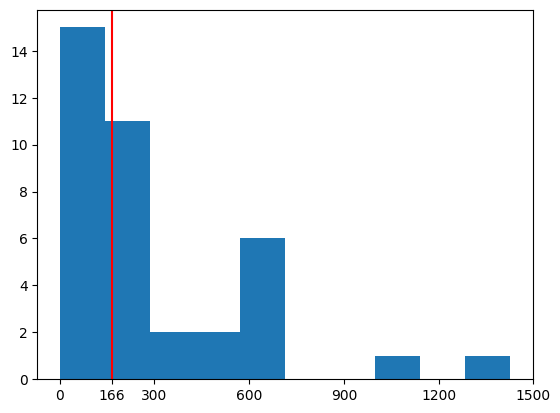

In [19]:
texts = train['имя'].tolist()
poyavleniya_vseh_bukov = list(Counter(''.join(texts)).values())
poyavleniya_vseh_bukov = np.array(poyavleniya_vseh_bukov)
mediana = int(np.median(poyavleniya_vseh_bukov))

plt.hist(poyavleniya_vseh_bukov)
plt.xticks([i*300 for i in range(6)]+[mediana])
# plt.xlim((0,500))
plt.axvline(mediana, c='r')
plt.show()

In [20]:
tokenizer = CharTokenizer(max_len=mediana)
tokenizer.fit(texts)

Так называемое создание словаря из буков:   0%|          | 0/38 [00:00<?, ?it/s]

In [21]:
tokenizer.vocab_size

40

In [22]:
max_len = int(train['имя'].str.len().max()) # Товарищ Gemini 3.1 Pro предложил взять это как max_len. попробуем оба варианта
max_len

22

In [23]:
class PetsDataset(Dataset):
    def __init__(self, names: List[str], labels: List[int], tokenizer: CharTokenizer, max_len:int):
        self.names = names
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
        
    def __len__(self) -> int:
        return len(self.names)
    
    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        name = self.names[idx]
        label = self.labels[idx]

        true_len = min(len(name), self.max_len)
        encoded_name = self.tokenizer.encode(name)
        x_tensor = torch.tensor(encoded_name, dtype=torch.long)
        y_tensor = torch.tensor(label, dtype=torch.long)
        
        return x_tensor, y_tensor, true_len
    

In [24]:
train_dataset = PetsDataset(
    names=train['имя'].tolist(),
    labels=train['label_idx'].tolist(),
    tokenizer=tokenizer,
    max_len=max_len
    )

test_dataset = PetsDataset(
    names=test['имя'].tolist(),
    labels=test['label_idx'].tolist(),
    tokenizer=tokenizer,
    max_len=max_len
)

print(len(train_dataset))
print(len(test_dataset))

1915
479


удивительно, но размеры DataFrame'ов и Dataset'ов совпали...

<p class="task" id="3"></p>

3\. Решите задачу классификации категорий питомцев по их именам, используя 4 варианта рекуррентного слоя:
- собственная реализация из задачи 1
- `nn.RNN`
- `nn.LSTM`
- `nn.GRU`

Важно: используйте только последнее скрытое состояние RNN для предсказания.
При инициализации стандартных слоев (`nn.RNN` и др.) не забудьте указать параметр `batch_first`.

Базовая архитектура самой сети с точностью до рекуррентного слоя одинаковая - nn.Embedding -> RNN -> FC (не забудьте функции нелинейности). Вы также можете добавить любые другие слои по слоему усмотрению.

Выведите на экран сравнительную таблицу:
- модель
- время обучения
- accuracy на тестовой выборке


- [ ] Проверено на семинаре

In [25]:
class IvanTishchenkoIsPetClassifierPL(pl.LightningModule):
    def __init__(self, vocab_size: int, num_classes: int, rnn_type: str, embed_dim: int = 64, hidden_dim: int = 128):
        super().__init__()
        self.save_hyperparameters()
        self.rnn_type = rnn_type
        
        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim, padding_idx=0)
        
        if rnn_type == 'my':
            self.rnn = RNN(input_size=embed_dim, hidden_size=hidden_dim)
        elif rnn_type == 'rnn':
            self.rnn = nn.RNN(input_size=embed_dim, hidden_size=hidden_dim, batch_first=True)
        elif rnn_type == 'lstm':
            self.rnn = nn.LSTM(input_size=embed_dim, hidden_size=hidden_dim, batch_first=True)
        elif rnn_type == 'gru':
            self.rnn = nn.GRU(input_size=embed_dim, hidden_size=hidden_dim, batch_first=True)
        else:
            raise ValueError(f"Неизвестный тип RNN: {rnn_type}")
            
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )
        
        self.loss_fn = nn.CrossEntropyLoss()
        self.test_acc = MulticlassAccuracy(num_classes=num_classes, average='macro')

    def forward(self, x: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        # x: [Batch_Size, Seq_Len]
        emb = self.embedding(x) # ->[Batch_Size, Seq_Len, Embed_Dim]
        
        rnn_out = self.rnn(emb)
        
        if self.rnn_type == 'lstm':
            out, (h_n, _) = rnn_out
        else:
            out, h_n = rnn_out
            

        batch_size = x.size(0)
        last_char_indices = (lengths - 1).view(-1, 1).expand(batch_size, out.size(2)).unsqueeze(1)
        
        last_states = out.gather(1, last_char_indices).squeeze(1) 
                
        logits = self.fc(last_states)
        return logits

    def training_step(self, batch, batch_idx):
        x, y, lengths = batch
        logits = self(x, lengths)
        loss = self.loss_fn(logits, y)
        return loss

    def test_step(self, batch, batch_idx):
        x, y, lengths = batch
        logits = self(x, lengths)
        self.test_acc.update(logits, y)
        self.log('MulticlassAccuracy', self.test_acc, on_epoch=True)

        
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-3)

In [26]:
rnn_models =['my', 'rnn', 'lstm', 'gru']
results =[]
for cur_max_len in [mediana, max_len]:
    
    train_dataset = PetsDataset(
        names=train['имя'].tolist(),
        labels=train['label_idx'].tolist(),
        tokenizer=tokenizer,
        max_len=cur_max_len
        )

    test_dataset = PetsDataset(
        names=test['имя'].tolist(),
        labels=test['label_idx'].tolist(),
        tokenizer=tokenizer,
        max_len=cur_max_len
    )

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)
    
    for r_type in rnn_models:
        print(f"\nОбучение модели: {r_type.upper()}")
        
        model = IvanTishchenkoIsPetClassifierPL(vocab_size=tokenizer.vocab_size, num_classes=2, rnn_type=r_type)
        
        trainer = pl.Trainer(
            max_epochs=15, 
            accelerator='auto',
            enable_progress_bar=False,
            logger=False,
            enable_model_summary=False
        )
        
        start_time = time.time()
        trainer.fit(model, train_loader)
        train_time = time.time() - start_time
        
        test_results = trainer.test(model, test_loader, verbose=False)
        accuracy = test_results[0]['MulticlassAccuracy']
        
        results.append({
            "Обрезание" : cur_max_len,
            "Модель": r_type.upper(),
            "Время обучения (сек)": round(train_time, 2),
            "Test Accuracy": round(accuracy, 4)
        })

df_results = pd.DataFrame(results)

df_results

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 5070 Ti Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision



Обучение модели: MY


c:\Projects\FU\.venv\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:751: Checkpoint directory c:\Projects\FU\Course_3\NLP\03_rnn\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Projects\FU\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
`Trainer.fit` stopped: `max_epochs=15` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Projects\FU\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https


Обучение модели: RNN


`Trainer.fit` stopped: `max_epochs=15` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...


Обучение модели: LSTM


`Trainer.fit` stopped: `max_epochs=15` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Обучение модели: GRU


`Trainer.fit` stopped: `max_epochs=15` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


,Обрезание,Модель,Время обучения (сек),Test Accuracy
0,166,MY,39.24,0.7841
1,166,RNN,2.50,0.8012
2,166,LSTM,2.47,0.8158
3,166,GRU,2.58,0.8148
4,22,MY,36.40,0.7722
5,22,RNN,2.57,0.7759
6,22,LSTM,2.48,0.8260
7,22,GRU,2.67,0.7912


Вывод очевиден. Чем больше обрезание, тем лучше.

<p class="task" id="4"></p>

4\. Считайте файл `pos_data.txt` и создайте на его основе два списка `X` и `y` следующего вида.

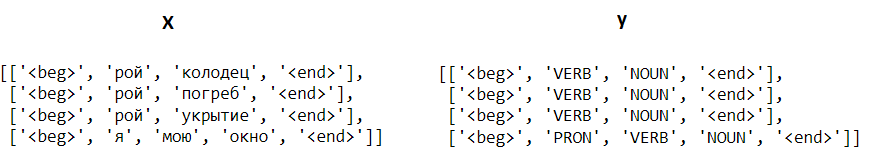

Разделите данные на обучающую и тестовую выборку. Создайте два Tokenizer на основе загруженных данных: `tokenizer_X` для слов и `tokenizer_y` для частей речи. Добавьте в словари специальные токены `<PAD>`, `<UNK>`. Выведите на экран количество токенов в полученных словарях.


- [ ] Проверено на семинаре

In [27]:
def parse_pos_data(file_path: str) -> Tuple[List[List[str]], List[List[str]]]:
    X, y = [], []
    current_words, current_tags = [], []
    
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in tqdm(f.readlines()):
            line = line.strip()
            if not line: 
                if current_words:
                    X.append(current_words)
                    y.append(current_tags)
                    current_words, current_tags = [], []
                continue
            
            parts = line.split('\t')
            if len(parts) < 3:
                continue
                
            word = parts[1]
            tag = parts[2].split('|')[0]
            
            current_words.append(word)
            current_tags.append(tag)
            
    if current_words:
        X.append(current_words)
        y.append(current_tags)
        
    return X, y

X, y = parse_pos_data('data/pos_data.txt')

  0%|          | 0/11249881 [00:00<?, ?it/s]

In [28]:
X[:4]

[['<beg>', 'рой', 'колодец', '<end>'],
 ['<beg>', 'рой', 'погреб', '<end>'],
 ['<beg>', 'рой', 'укрытие', '<end>'],
 ['<beg>', 'я', 'мою', 'окно', '<end>']]

In [29]:
y[:4]

[['<beg>', 'VERB', 'NOUN', '<end>'],
 ['<beg>', 'VERB', 'NOUN', '<end>'],
 ['<beg>', 'VERB', 'NOUN', '<end>'],
 ['<beg>', 'PRON', 'VERB', 'NOUN', '<end>']]

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [31]:
class WordTokenizer:
    def __init__(self, use_lemma: bool = True):
        self.token2idx: Dict[str, int] = {'<PAD>': 0, '<UNK>': 1}
        self.idx2token: Dict[int, str] = {0: '<PAD>', 1: '<UNK>'}
        self.vocab_size = 2
        self.use_lemma = use_lemma
        
        if self.use_lemma:
            self.morph = pymorphy3.MorphAnalyzer()

    def _normalize(self, token: str) -> str:
        if not self.use_lemma:
            return token.lower()
        
        if token.startswith('<') and token.endswith('>'):
            return token
            
        return self.morph.parse(token)[0].normal_form

    def fit(self, data: List[List[str]]):
        for sentence in tqdm(data, desc="Обрабатываем предложения"):
            for token in sentence:
                norm_token = self._normalize(token)
                if norm_token not in self.token2idx:
                    self.token2idx[norm_token] = self.vocab_size
                    self.idx2token[self.vocab_size] = norm_token
                    self.vocab_size += 1
                    
    def encode(self, sentence: List[List[str]]) -> List[int]:
        return [
            self.token2idx.get(self._normalize(token), self.token2idx['<UNK>']) 
            for token in sentence
        ]
        
tokenizer_X = WordTokenizer()
tokenizer_X.fit(X_train)

tokenizer_X_nl = WordTokenizer(use_lemma=False)
tokenizer_X_nl.fit(X_train)

tokenizer_y = WordTokenizer(use_lemma=False)
tokenizer_y.fit(y_train)

print(f"tokenizer_X.shape = {tokenizer_X.vocab_size}")
print(f"tokenizer_X_nl.shape = {tokenizer_X_nl.vocab_size}")
print(f"y.shape = {tokenizer_y.vocab_size}")
print(f"Список тегов \n{list(tokenizer_y.token2idx.keys())}")

Обрабатываем предложения:   0%|          | 0/792052 [00:00<?, ?it/s]

Обрабатываем предложения:   0%|          | 0/792052 [00:00<?, ?it/s]

Обрабатываем предложения:   0%|          | 0/792052 [00:00<?, ?it/s]

tokenizer_X.shape = 109511
tokenizer_X_nl.shape = 308889
y.shape = 20
Список тегов 
['<PAD>', '<UNK>', '<beg>', 'adj', 'noun', 'verb', 'adv', 'part', 'punct', '<end>', 'pron', 'adp', 'conj', 'num', 'x', 'h', 'det', 'latn', 'intj', 'sym']


<p class="task" id="5"></p>

5\. Создайте класс `POSTaggingDataset`. Реализуйте `__getitem__` таким образом, чтобы он возвращал кортеж `(x, y)`, где x - это набор индексов токенов для предложений на русском языке, а `y` - набор индексов токенов для соответствующих частей речи. Cделайте длины наборов индексов одинаковой фиксированной длины. Ограничьте длину слишком длинных последовательностей значением `max_len` (подберите подходящую величину самостоятельно).

Создайте два датасета: для обучающей и тестовой выборки.

Выведите на экран формы тензоров `x` и `y`:

```python
x, y = train_dset[:5]
print(x.shape, y.shape)
```



- [ ] Проверено на семинаре

In [32]:
class POSTaggingDataset(Dataset):
    def __init__(
        self, 
        X: List[List[str]], 
        y: List[List[str]], 
        tokenizer_X, 
        tokenizer_y, 
        max_len: int
    ):
        self.X = X
        self.y = y
        self.tokenizer_X = tokenizer_X
        self.tokenizer_y = tokenizer_y
        self.max_len = max_len
        self.trumpcat = PadTruncate(n=max_len, pad_idx=0)

    def __len__(self) -> int:
        return len(self.X)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        words = self.X[idx]
        tags = self.y[idx]

        x_indices = self.tokenizer_X.encode(words)
        y_indices = self.tokenizer_y.encode(tags)

        x_padded = self.trumpcat(x_indices)
        y_padded = self.trumpcat(y_indices)

        return (
            torch.tensor(x_padded, dtype=torch.long), 
            torch.tensor(y_padded, dtype=torch.long)
        )

9


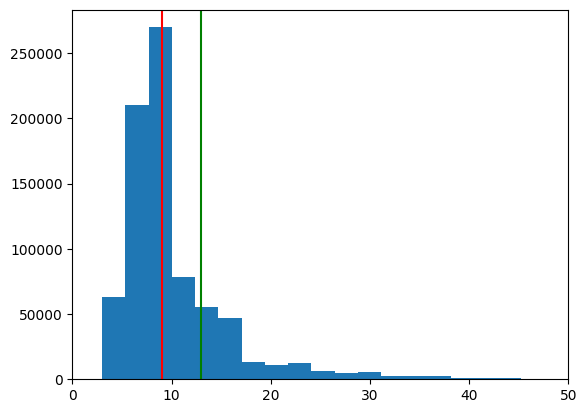

In [33]:
MAX_LEN = 13

X_train_lens = np.array(list(map(lambda x: len(x), X_train)))
mediana = int(np.median(X_train_lens))
plt.hist(X_train_lens, bins=200)
# plt.xticks([i*300 for i in range(6)]+[mediana])
plt.axvline(mediana, c='r')
plt.axvline(MAX_LEN, c='g')

plt.xlim(0,50)
print(mediana)

In [34]:

train_dset_l = POSTaggingDataset(
    X=X_train, 
    y=y_train, 
    tokenizer_X=tokenizer_X, 
    tokenizer_y=tokenizer_y, 
    max_len=MAX_LEN
)

train_dset_nl = POSTaggingDataset(
    X=X_train, 
    y=y_train, 
    tokenizer_X=tokenizer_X_nl, 
    tokenizer_y=tokenizer_y, 
    max_len=MAX_LEN
)

test_dset = POSTaggingDataset(
    X=X_test, 
    y=y_test, 
    tokenizer_X=tokenizer_X, 
    tokenizer_y=tokenizer_y, 
    max_len=MAX_LEN
)


In [35]:
samples_x = []
samples_y = []
for i in range(5):
    xi, yi = train_dset_l[i]
    samples_x.append(xi)
    samples_y.append(yi)

x_batch = torch.stack(samples_x)
y_batch = torch.stack(samples_y)

print(f"Форма X: {x_batch.shape}") # Ожидаем [5, MAX_LEN]
print(f"Форма y: {y_batch.shape}") # Ожидаем [5, MAX_LEN]

Форма X: torch.Size([5, 13])
Форма y: torch.Size([5, 13])


<p class="task" id="6"></p>

6\. Создайте и обучите модель для предсказания частей речи.

Базовая архитектура модели: `nn.Embedding` -> RNN -> FC.

Для настройки используйте функцию потерь `nn.CrossEntropyLoss`. Обязательно используйте параметр `ignore_index`, чтобы не учитывать ошибку на токенах `<PAD>`.

Во время обучения выводите на экран значения функции потерь для эпохи, значение accuracy для эпохи. Постройте и выведите на экран classification report на основе тестовой выборки. При расчетах этих величин обязательно игноруйте паддинги.

Выведите на экран пример предсказания частей речи обученной моделью.

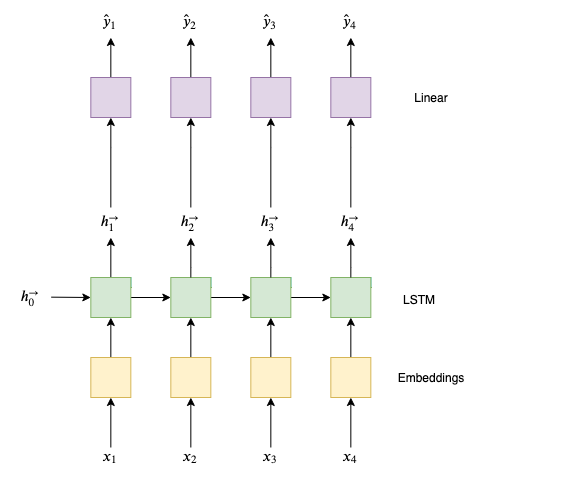

- [ ] Проверено на семинаре

In [41]:
class POSTagger(pl.LightningModule):
    def __init__(self, vocab_size, num_classes, weights, embed_dim=128, hidden_dim=256):
        super().__init__()
        self.save_hyperparameters()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True, bidirectional=False)
        self.classifier = nn.Linear(hidden_dim, num_classes)
        self.loss_fn = nn.CrossEntropyLoss(weight=weights, ignore_index=0)
        
        self.train_acc = MulticlassAccuracy(num_classes=num_classes, ignore_index=0)
        self.test_acc = MulticlassAccuracy(num_classes=num_classes, ignore_index=0)

    def forward(self, x):
        embeds = self.embedding(x)
        rnn_out, _ = self.rnn(embeds)
        logits = self.classifier(rnn_out)
        return logits

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        

        logits_flat = logits.view(-1, self.hparams.num_classes)
        y_flat = y.view(-1)
        
        loss = self.loss_fn(logits_flat, y_flat)
        acc = self.train_acc(logits_flat, y_flat)
        
        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('train_acc', acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        logits_flat = logits.view(-1, self.hparams.num_classes)
        y_flat = y.view(-1)
        
        self.test_acc.update(logits_flat, y_flat)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-3)

In [42]:
def calculate_class_weights(y_data, tokenizer_y):
    all_tags = [tag for sentence in y_data for tag in sentence]
    counts = Counter(all_tags)
    weights = np.zeros(tokenizer_y.vocab_size, dtype=np.float32)
    
    total_samples = len(all_tags)
    num_classes = tokenizer_y.vocab_size
    
    for token, idx in tokenizer_y.token2idx.items():
        if token == '<PAD>':
            weights[idx] = 0.0
            continue
        
        count = counts.get(token, 0)
        if count > 0:
            weights[idx] = total_samples / (num_classes * count)
        else:
            weights[idx] = 1.0
            
    weights = weights / weights[weights > 0].mean()
    
    return torch.tensor(weights)

class_weights = calculate_class_weights(y_train, tokenizer_y)
class_weights

tensor([0.0000, 1.0535, 0.5455, 1.0535, 1.0535, 1.0535, 1.0535, 1.0535, 1.0535,
        0.5455, 1.0535, 1.0535, 1.0535, 1.0535, 1.0535, 1.0535, 1.0535, 1.0535,
        1.0535, 1.0535])

In [43]:
def get_report(model, loader, tokenizer_y):
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for x, y in loader:
            logits = model(x)
            preds = torch.argmax(logits, dim=-1)
            
            mask = (y != 0)
            all_preds.extend(preds[mask].cpu().numpy())
            all_targets.extend(y[mask].cpu().numpy())
            

    eval_labels = list(range(1, tokenizer_y.vocab_size))
    
    target_names = [tokenizer_y.idx2token[i] for i in eval_labels]
    

    print(classification_report(
        all_targets, 
        all_preds, 
        labels=eval_labels,
        target_names=target_names,
        zero_division=0
    ))

train_dset_dict = {
    "no lemmatisation" : (train_dset_nl, tokenizer_X_nl),
    "+ lemmatisation" : (train_dset_l, tokenizer_X)
}

for name, (train_dset, tokeni_X) in train_dset_dict.items():
    
    train_loader = DataLoader(train_dset, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_dset, batch_size=64)

    model = POSTagger(
        vocab_size=tokeni_X.vocab_size, 
        num_classes=tokenizer_y.vocab_size,
        weights=class_weights
    )

    trainer = pl.Trainer(max_epochs=5, accelerator='auto')
    trainer.fit(model, train_loader, test_loader)

    print(name.upper())
    get_report(model, test_loader, tokenizer_y)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type               | Params | Mode 
----------------------------------------------------------
0 | embedding  | Embedding          | 39.5 M | train
1 | rnn        | GRU                | 296 K  | train
2 | classifier | Linear             | 5.1 K  | train
3 | loss_fn    | CrossEntropyLoss   | 0      | train
4 | train_acc  | MulticlassAccuracy | 0      | train
5 | test_acc   | MulticlassAccuracy | 0      | train
----------------------------------------------------------
39.8 M    Trainable params
0         Non-trainable params
39.8 M    Total params
159.358   Total estimated model params size (MB)
6         Modules

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Projects\FU\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
c:\Projects\FU\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.


+ LEMMATISATION
              precision    recall  f1-score   support

       <UNK>       0.00      0.00      0.00         0
       <beg>       1.00      1.00      1.00    198014
         adj       0.91      0.94      0.92    155935
        noun       0.99      0.98      0.99    326752
        verb       0.97      0.98      0.98    242089
         adv       0.92      0.93      0.93     87512
        part       0.93      0.90      0.92     43113
       punct       1.00      1.00      1.00    250900
       <end>       1.00      1.00      1.00    162757
        pron       0.96      0.97      0.97    116741
         adp       1.00      1.00      1.00    112875
        conj       0.94      0.94      0.94     60323
         num       0.93      0.89      0.91     13048
           x       0.43      0.35      0.39      2212
           h       0.55      0.49      0.52      1477
         det       0.62      0.08      0.14      1574
        latn       0.89      0.67      0.76      1952
        int

С лемматизацией лучше. Но с такими даталоадерами 2 модели обучались 112 минут...

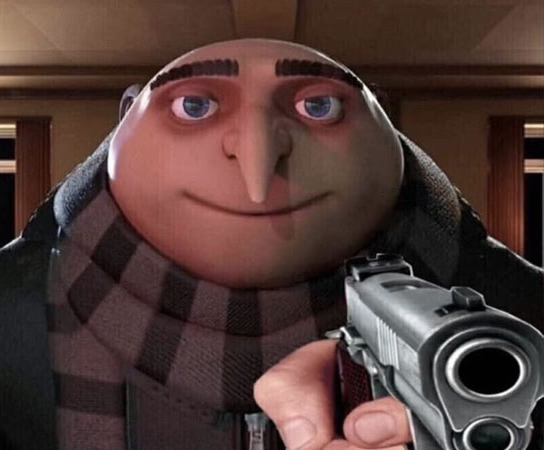

[[chislo],...] -> [ chislo, ...]

<p class="task" id="7"></p>

7*\. Решите задачу 6, используя двунаправленный рекуррентный слой. Сравните макро-F1 score с однонаправленной моделью. Сделайте вывод, помог ли контекст "справа" лучше определять части речи.


- [ ] Проверено на семинаре

In [46]:
class BiPOSTagger(pl.LightningModule):
    def __init__(self, vocab_size, num_classes, weights, embed_dim=128, hidden_dim=256, bidirectional=True):
        super().__init__()
        self.save_hyperparameters()
        self.bidirectional = bidirectional
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.GRU(
            embed_dim, 
            hidden_dim, 
            batch_first=True, 
            bidirectional=bidirectional
        )
        classifier_input_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.classifier = nn.Linear(classifier_input_dim, num_classes)
        self.loss_fn = nn.CrossEntropyLoss(weight=weights, ignore_index=0)
        
        self.f1_score = MulticlassF1Score(
            num_classes=num_classes, 
            average='macro', 
            ignore_index=0
        )

    def forward(self, x):
        embeds = self.embedding(x)
        rnn_out, _ = self.rnn(embeds)
        logits = self.classifier(rnn_out)
        return logits

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits.view(-1, self.hparams.num_classes), y.view(-1))
        self.log('train_loss', loss, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        self.f1_score.update(logits.view(-1, self.hparams.num_classes), y.view(-1))

    def on_validation_epoch_end(self):
        f1 = self.f1_score.compute()
        self.log('val_f1', f1, prog_bar=True)
        self.f1_score.reset()

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-3)


In [ ]:


def compare_models(train_loader, test_loader, vocab_size, num_classes):
    results = []
    
    for is_bi in [False, True]:
        mode_name = "Bidirectional" if is_bi else "Unidirectional"
        print(f"\nОбучение {mode_name} модели")
        
        model = BiPOSTagger(vocab_size, num_classes, weights=class_weights, bidirectional=is_bi)
        trainer = pl.Trainer(
            max_epochs=5, 
            accelerator='auto', 
            enable_model_summary=False,
            logger=False
        )
        
        start_time = time.time()
        trainer.fit(model, train_loader, test_loader)
        elapsed = time.time() - start_time
        
        test_f1 = trainer.validate(model, test_loader, verbose=False)[0]['val_f1']
        
        results.append({
            "Модель": mode_name,
            "Время (сек)": round(elapsed, 2),
            "Macro-F1": round(test_f1, 4)
        })
        
    return results

res = []
for name, (train_dset, tokeni_X) in train_dset_dict.items():
    
    train_loader = DataLoader(train_dset, batch_size=4096, shuffle=True)
    test_loader = DataLoader(test_dset, batch_size=4096)

    comparison_results = compare_models(train_loader, test_loader, tokeni_X.vocab_size, tokenizer_y.vocab_size)
    res = res + comparison_results



💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Обучение Unidirectional модели


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |          | 0/? [00:00<?, ?it/s]

,Модель,Время (сек),Macro-F1
0,Unidirectional,1991.97,0.7312
1,Bidirectional,1976.93,0.7801


In [52]:
pd.DataFrame(res)

,Модель,Время (сек),Macro-F1
0,Unidirectional,539.32,0.2202
1,Bidirectional,541.87,0.2215
2,Unidirectional,1991.97,0.7312
3,Bidirectional,1976.93,0.7801


Как итог - лемматизация это круто.

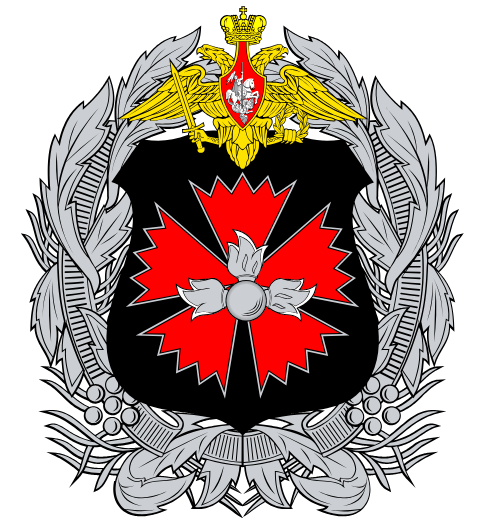